# SE4050 Deep Learning 2026 - ResNet50 Road-Damage Classification

Multi-label classification of road-damage patches into `D00`, `D10`, `D20`,
`D40` with an ImageNet-pretrained ResNet50 (member **IT23325814**). The notebook
is fully self-contained: every function it needs is defined in the cells below
(no imports from other project files).

| Decision | Choice | Reason |
|---|---|---|
| Task | multi-label (sigmoid + BCE) | same task as the group's VGG16 baseline |
| Data | `data/train` Czech + India XML labels (4,295 labelled images) | Japan and test1/test2 ship without damage annotations |
| Split | 70/15/15 grouped by near-duplicate, seed 42 | identical algorithm to the shared manifest - no leakage |
| Backbone | ResNet50 + ImageNet weights, frozen | 2,048-d global-average-pool features, CPU-friendly |
| Head | 256-unit MLP + dropout | mirrors the VGG16 head for a fair comparison |
| Test set | touched once, at the end | assignment rule |

Settings are hard-coded below (self-contained); everything is written to
`results/IT23325814/` and `src/IT23325814/models/`.

## 1. Setup

Project root detection, configuration, seeding and small helpers. The root is
found by walking up from the notebook directory until `requirements.txt` is
seen, so the notebook works from any folder layout.

In [1]:
import collections
import hashlib
import json
import os
import random
import time
from pathlib import Path
from xml.etree import ElementTree as ET

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
print("project root:", ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=_json_default)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, Path):
        return str(o)
    raise TypeError(f"Object of type {type(o)} is not JSON serializable")


class Timer:
    def __enter__(self):
        self.t0 = time.time()
        return self

    def __exit__(self, *exc):
        self.elapsed = time.time() - self.t0


def hashlib_md5(text):
    return hashlib.md5(text.encode("utf-8")).hexdigest()


class Config:
    data_dir: Path = ROOT / "data"
    train_dir: Path = ROOT / "data" / "train"
    results_dir: Path = ROOT / "results" / "IT23325814"
    models_dir: Path = ROOT / "src" / "IT23325814" / "models"

    img_size: int = 224
    batch_size: int = 64
    num_classes: int = 4
    class_names: list = ["D00", "D10", "D20", "D40"]

    seed: int = 42
    test_size: float = 0.15
    val_size: float = 0.15

    head_epochs: int = 100
    head_lr: float = 0.001
    dropout: float = 0.5
    patience_earlystop: int = 12
    patience_lr: int = 5

    checkpoint_path: Path = models_dir / "resnet50_multilabel.keras"
    head_weights: Path = models_dir / "resnet50_head.weights.h5"
    history_path: Path = results_dir / "metrics" / "training_history.json"
    features_cache: Path = results_dir / "cache" / "resnet50_features.npz"

    @classmethod
    def ensure_dirs(cls):
        cls.models_dir.mkdir(parents=True, exist_ok=True)
        for sub in ("figures", "metrics", "cache", "predictions", "tables"):
            (cls.results_dir / sub).mkdir(parents=True, exist_ok=True)

    @classmethod
    def as_dict(cls):
        return {
            "data_dir": str(cls.data_dir),
            "img_size": cls.img_size,
            "batch_size": cls.batch_size,
            "num_classes": cls.num_classes,
            "class_names": cls.class_names,
            "seed": cls.seed,
            "test_size": cls.test_size,
            "val_size": cls.val_size,
            "head_epochs": cls.head_epochs,
            "head_lr": cls.head_lr,
            "dropout": cls.dropout,
            "patience_earlystop": cls.patience_earlystop,
            "patience_lr": cls.patience_lr,
            "checkpoint_path": str(cls.checkpoint_path),
            "features_cache": str(cls.features_cache),
        }


set_global_seed(Config.seed)
Config.ensure_dirs()
RUN = {"model": "ResNet50", "member": "IT23325814"}
print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none - CPU pipeline")

project root: C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment


TensorFlow 2.21.0


GPU: none - CPU pipeline


## 2. Dataset validation and EDA

Scans `data/train`, `data/test1`, `data/test2` (corruption + duplicate check),
parses the VOC annotations of `train/Czech` and `train/India`, and writes
`metrics/dataset_stats.json`, `metrics/label_table.csv` and the EDA figures.

In [2]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
stats_global = {}


def scan_images():
    '''One row per image across the train/test1/test2 folders.'''
    rows = []
    for split in ("train", "test1", "test2"):
        split_dir = Config.data_dir / split
        if not split_dir.is_dir():
            continue
        for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
            images_dir = class_dir / "images"
            if not images_dir.is_dir():
                continue
            for img in sorted(images_dir.iterdir()):
                if img.suffix.lower() in IMAGE_EXTS:
                    rows.append({
                        "split": split,
                        "source": class_dir.name,
                        "path": img,
                        "bytes": img.stat().st_size,
                    })
    return pd.DataFrame(rows)


def check_images(df):
    '''Open every image; returns status, size and corrupt-file list.'''
    statuses, widths, heights, corrupt = [], [], [], []
    for p in df["path"]:
        try:
            with Image.open(p) as im:
                im.verify()
            with Image.open(p) as im:
                im.load()
                widths.append(im.width)
                heights.append(im.height)
            statuses.append("ok")
        except Exception as exc:
            statuses.append("corrupt")
            widths.append(np.nan)
            heights.append(np.nan)
            corrupt.append({"path": str(p), "error": f"{type(exc).__name__}: {exc}"})
    return statuses, widths, heights, corrupt


def exact_duplicates(df):
    '''Byte-identical images, grouped by content MD5.'''
    by_hash = collections.defaultdict(list)
    for p in df["path"]:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        by_hash[h].append(str(p))
    return [v for v in by_hash.values() if len(v) > 1]


def parse_damage_labels():
    '''Multi-label table from the train/Czech + train/India VOC xml files.'''
    rows = []
    for country in ("Czech", "India"):
        xml_dir = Config.train_dir / country / "annotations" / "xmls"
        if not xml_dir.is_dir():
            continue
        for xml_path in sorted(xml_dir.glob("*.xml")):
            root = ET.parse(xml_path).getroot()
            objects = root.findall("object")
            classes = sorted(
                {o.findtext("name") for o in objects
                 if o.findtext("name") in Config.class_names}
            )
            img = xml_path.parents[2] / "images" / (xml_path.stem + ".jpg")
            if not img.exists():
                continue
            row = {"path": str(img), "source": country, "n_objects": len(objects)}
            for c in Config.class_names:
                row[c] = int(c in classes)
            row["labels"] = classes
            rows.append(row)
    return pd.DataFrame(rows)


def label_statistics(labels_df):
    return {
        "annotated_images": int(len(labels_df)),
        "images_with_no_object": int((labels_df["n_objects"] == 0).sum()),
        "images_with_target_label": int(labels_df[Config.class_names].sum(axis=1).gt(0).sum()),
        "images_without_target_label": int(labels_df[Config.class_names].sum(axis=1).eq(0).sum()),
        "per_class_images": {
            c: int(labels_df[c].sum()) for c in Config.class_names
        },
        "multi_label_images": int((labels_df[Config.class_names].sum(axis=1) > 1).sum()),
        "per_source": labels_df["source"].value_counts().to_dict(),
    }


def validate_dataset():
    print("Scanning dataset ...")
    df = scan_images()
    statuses, widths, heights, corrupt = check_images(df)
    df["status"] = statuses
    df["width"] = widths
    df["height"] = heights
    ok = df[df["status"] == "ok"]
    print(f"images: {len(df)}  ok={len(ok)}  corrupt={len(corrupt)}")

    dup_groups = exact_duplicates(df)
    print(f"exact duplicate groups: {len(dup_groups)}")

    print("Parsing damage labels ...")
    labels_df = parse_damage_labels()
    label_stats = label_statistics(labels_df)
    stats_global.update(label_stats)

    stats = {
        "total_images": int(len(df)),
        "per_split": df["split"].value_counts().to_dict(),
        "per_split_source": (
            df.groupby(["split", "source"]).size().unstack(fill_value=0).to_dict()),
        "corrupt_images": corrupt,
        "exact_duplicate_groups": dup_groups,
        "labels": label_stats,
        "notes": [
            "Damage labels cover train/Czech and train/India (VOC xml). "
            "4295 of the 10535 annotated images carry at least one of the four "
            "target classes; the rest carry only non-target RDD tags and are "
            "excluded from damage training. Japan train images and test1/test2 "
            "ship without damage annotations.",
            "Japan images and test1/test2 are used only for dataset "
            "description, not for damage evaluation.",
        ],
    }
    save_json(stats, Config.results_dir / "metrics" / "dataset_stats.json")
    df.drop(columns="path").assign(
        path=[str(p) for p in df["path"]]
    ).to_csv(Config.results_dir / "metrics" / "image_inventory.csv", index=False)
    labels_df.drop(columns="path").assign(
        path=[str(p) for p in labels_df["path"]]
    ).to_csv(Config.results_dir / "metrics" / "label_table.csv", index=False)
    print("Saved dataset stats to", Config.results_dir)
    return stats, df, labels_df

In [3]:
stats, inventory_df, labels_df_raw = validate_dataset()

print("images per split:", stats["per_split"])
print("corrupt images  :", stats["corrupt_images"])
print("duplicate groups:", len(stats["exact_duplicate_groups"]))
print()
for k, v in stats["labels"].items():
    print(f"  {k}: {v}")

Scanning dataset ...


images: 18437  ok=18436  corrupt=1


exact duplicate groups: 0
Parsing damage labels ...


Saved dataset stats to C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\results\IT23325814
images per split: {'train': 13142, 'test2': 2664, 'test1': 2631}
corrupt images  : [{'path': 'C:\\Users\\ASUS\\Desktop\\SLIIT\\Year 4\\Semester 2\\Deep Learning\\Assignment\\SE4050-Deep-Learning-Assignment\\data\\train\\Japan\\images\\Japan_004643.jpg', 'error': 'OSError: image file is truncated (16 bytes not processed)'}]
duplicate groups: 0

  annotated_images: 10535
  images_with_no_object: 5678
  images_with_target_label: 4295
  images_without_target_label: 6240
  per_class_images: {'D00': 1873, 'D10': 360, 'D20': 1887, 'D40': 1684}
  multi_label_images: 1300
  per_source: {'India': 7706, 'Czech': 2829}


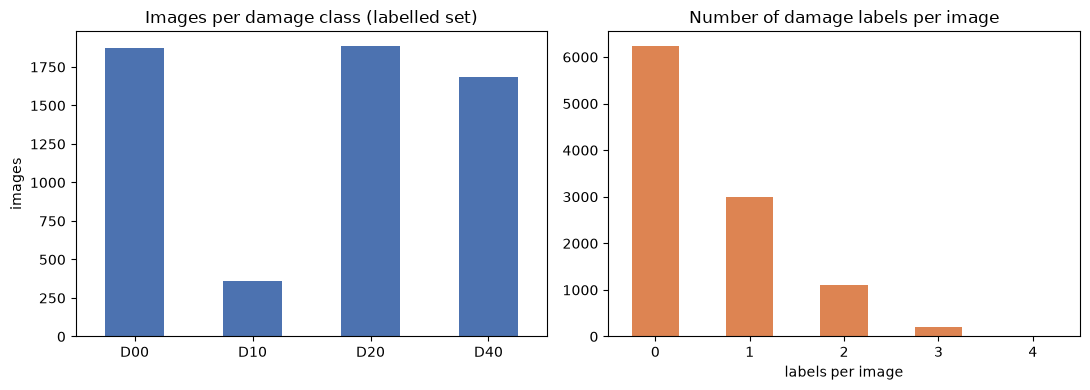

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
per_class = labels_df_raw[Config.class_names].sum()
per_class.plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Images per damage class (labelled set)")
axes[0].set_ylabel("images")
axes[0].tick_params(axis="x", rotation=0)

n_labels = labels_df_raw[Config.class_names].sum(axis=1)
n_labels.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#dd8452")
axes[1].set_title("Number of damage labels per image")
axes[1].set_xlabel("labels per image")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "class_distribution.png")
plt.show()

## 3. Labels and leakage-safe split

* keep images with at least one of the four classes (4,295 images);
* cluster near-duplicates with a 64-bit dHash (Hamming <= 4);
* assign whole clusters to train/val/test 70/15/15, so duplicates never
  cross a split;
* cross-check the result against the group's shared manifest
  (`results/IT22064868/metrics/split_manifest.csv`) - same algorithm and seed
  must give the same split.

In [5]:
MANIFEST_PATH = Config.results_dir / "metrics" / "split_manifest.csv"
SHARED_MANIFEST = ROOT / "results" / "IT22064868" / "metrics" / "split_manifest.csv"
NEAR_DUP_MAX_HAMMING = 4   # 64-bit dHash: <=4 means visually near-identical


def build_label_table():
    '''Images that carry at least one of the four damage labels.'''
    df = parse_damage_labels()
    n_main = df[Config.class_names].sum(axis=1)
    df = df[n_main > 0].reset_index(drop=True)
    df["primary"] = df[Config.class_names].idxmax(axis=1)
    return df


def dhash(path, size=8):
    '''64-bit difference hash (resize + grey, compare neighbours).'''
    with Image.open(path) as im:
        g = im.convert("L").resize((size + 1, size), Image.LANCZOS)
        pixels = np.asarray(g)
    bits = 0
    for row in range(size):
        for col in range(size):
            bits = (bits << 1) | (1 if pixels[row, col] > pixels[row, col + 1] else 0)
    return bits


def _hamming_matrix(hashes, chunk=256):
    '''Pairwise Hamming distances of 64-bit hashes, chunked to save memory.'''
    b = np.unpackbits(hashes.view(np.uint8).reshape(hashes.size, 8), axis=1)
    n = b.shape[0]
    dist = np.empty((n, n), dtype=np.int16)
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        diff = b[start:end, None, :] != b[None, :, :]
        dist[start:end] = diff.sum(axis=2)
    return dist


def find_near_duplicate_clusters(paths, max_hamming=NEAR_DUP_MAX_HAMMING):
    '''Union-Find over perceptually near-identical images.'''
    hashes = np.array([dhash(p) for p in paths], dtype=np.uint64)
    dist = _hamming_matrix(hashes)
    n = len(paths)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    iu = np.triu_indices(n, k=1)
    close = np.where(dist[iu] <= max_hamming)[0]
    for idx in close:
        union(int(iu[0][idx]), int(iu[1][idx]))

    groups = collections.defaultdict(list)
    for i in range(n):
        groups[find(i)].append(i)
    clusters = sorted((sorted(v) for v in groups.values()), key=lambda c: -len(c))
    return clusters, hashes


def _greedy_cluster_split(df, clusters):
    '''Assign whole clusters to train/val/test, hitting per-class targets.'''
    rng = np.random.default_rng(Config.seed)
    n = len(df)
    primaries = df["primary"].to_numpy()
    split = np.full(n, "", dtype=object)
    used = collections.Counter()

    cluster_primary = []
    for cl in clusters:
        votes = collections.Counter(primaries[cl])
        cluster_primary.append(votes.most_common(1)[0][0])

    order = np.arange(len(clusters))
    rng.shuffle(order)

    class_totals = collections.Counter(primaries)
    progress = collections.defaultdict(lambda: {"test": 0.0, "val": 0.0})

    for ci in order:
        cl = clusters[ci]
        label = cluster_primary[ci]
        size = len(cl)
        deficit = {}
        for sp, target in (("test", Config.test_size), ("val", Config.val_size)):
            want = class_totals[label] * target
            deficit[sp] = want - progress[label][sp]
        if deficit["test"] >= deficit["val"] and deficit["test"] > 0:
            choice = "test"
        elif deficit["val"] > 0:
            choice = "val"
        else:
            choice = "train"
        for i in cl:
            split[i] = choice
        progress[label][choice] = progress[label].get(choice, 0.0) + size
        used[choice] += size

    for sp in ("train", "val", "test"):
        if used[sp] == 0:
            raise RuntimeError(f"empty split: {sp}")
    return pd.Series(split, index=df.index, name="split")


def create_or_load_split(force=False):
    '''Label table + split column; a saved manifest is reused.'''
    df = build_label_table()
    if MANIFEST_PATH.exists() and not force:
        manifest = pd.read_csv(MANIFEST_PATH)
        if list(manifest["path"]) == list(df["path"]):
            df["split"] = manifest["split"]
            df["cluster_id"] = manifest["cluster_id"]
            print("Loaded existing split manifest:", MANIFEST_PATH)
            return df
        print("Manifest does not match current data - rebuilding split.")

    print("Computing perceptual hashes / near-duplicate clusters ...")
    clusters, hashes = find_near_duplicate_clusters(list(df["path"]))
    multi = [c for c in clusters if len(c) > 1]
    print(f"{len(df)} images -> {len(clusters)} clusters "
          f"({len(multi)} with duplicates)")

    print("Assigning leakage-safe splits ...")
    df["split"] = _greedy_cluster_split(df, clusters)

    df["cluster_id"] = -1
    for cid, cl in enumerate(clusters):
        df.loc[df.index[cl], "cluster_id"] = cid
    df.to_csv(MANIFEST_PATH, index=False)

    report = {
        "n_images": int(len(df)),
        "n_clusters": int(len(clusters)),
        "n_clusters_with_duplicates": int(len(multi)),
        "largest_cluster": int(max(len(c) for c in clusters)),
        "split_counts": df["split"].value_counts().to_dict(),
        "per_class_split": (
            df.groupby("split")[Config.class_names].sum().astype(int).to_dict()
        ),
        "per_source_split": pd.crosstab(df["split"], df["source"]).to_dict(),
    }
    save_json(report, Config.results_dir / "metrics" / "split_report.json")
    print("Saved split manifest ->", MANIFEST_PATH)
    return df


def leakage_report(df):
    '''Checks that no cluster and no path crosses split boundaries.'''
    cluster_splits = df.groupby("cluster_id")["split"].nunique()
    cross = cluster_splits[cluster_splits > 1]
    dup_paths = df["path"].duplicated().sum()
    return {
        "clusters_spanning_multiple_splits": int(len(cross)),
        "duplicate_paths": int(dup_paths),
        "split_counts": df["split"].value_counts().to_dict(),
        "passed": bool(len(cross) == 0 and dup_paths == 0),
    }


def compare_with_shared_manifest(df):
    '''Read-only cross-check against the group's shared split manifest.'''
    if not SHARED_MANIFEST.exists():
        return {"available": False}
    shared = pd.read_csv(SHARED_MANIFEST)
    merged = df[["path", "split"]].merge(
        shared[["path", "split"]], on="path", suffixes=("", "_shared"))
    agreement = float((merged["split"] == merged["split_shared"]).mean())
    out = {
        "available": True,
        "matched_images": int(len(merged)),
        "agreement": agreement,
        "identical": bool(agreement == 1.0),
    }
    save_json(out, Config.results_dir / "metrics" / "shared_manifest_check.json")
    return out

In [6]:
with Timer():
    labels_df = create_or_load_split(force=True)

leak = leakage_report(labels_df)
print("leakage report:", leak)
assert leak["passed"], "split leakage detected"
RUN["leakage"] = leak

shared_check = compare_with_shared_manifest(labels_df)
print("shared-manifest cross-check:", shared_check)

print()
print("images per split:")
print(labels_df["split"].value_counts())
print()
print("label counts per split (multi-label):")
print(labels_df.groupby("split")[Config.class_names].sum())
print()
print("source per split:")
print(pd.crosstab(labels_df["split"], labels_df["source"]))

Computing perceptual hashes / near-duplicate clusters ...


4295 images -> 4095 clusters (82 with duplicates)
Assigning leakage-safe splits ...


Saved split manifest -> C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\results\IT23325814\metrics\split_manifest.csv
leakage report: {'clusters_spanning_multiple_splits': 0, 'duplicate_paths': 0, 'split_counts': {'train': 3005, 'val': 645, 'test': 645}, 'passed': True}
shared-manifest cross-check: {'available': True, 'matched_images': 4295, 'agreement': 1.0, 'identical': True}

images per split:
split
train    3005
val       645
test      645
Name: count, dtype: int64

label counts per split (multi-label):
        D00  D10   D20   D40
split                       
test    275   51   290   265
train  1312  259  1320  1165
val     286   50   277   254

source per split:
source  Czech  India
split               
test      137    508
train     772   2233
val       163    482


## 4. Feature extraction (frozen ResNet50)

One forward pass per image through the frozen ImageNet backbone
(`pooling='avg'` -> 2,048-d vector), cached in
`results/IT23325814/cache/resnet50_features*.npz`. The cache is reused only if
the image list, image size and backbone are unchanged.

In [7]:
def load_batch(paths, size):
    '''Read images, resize, apply ResNet50 (Caffe-style) normalization.'''
    batch = np.empty((len(paths), size, size, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        with open(p, "rb") as f:
            data = f.read()
        img = tf.io.decode_image(data, channels=3, expand_animations=False)
        img = tf.image.resize(img, (size, size), method="bilinear")
        batch[i] = img.numpy()
    return preprocess_input(batch)


backbone = ResNet50(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(Config.img_size, Config.img_size, 3),
)
backbone.trainable = False
print("backbone output:", backbone.output_shape)

EXTRACT_LOG = {}


def extract_features(paths, backbone, size, cache_path):
    '''Return (N, 2048) features, cached on disk.'''
    key = hashlib_md5("\n".join(paths) + f"|{size}|resnet50")
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        if str(cached["key"]) == key and len(cached["features"]) == len(paths):
            elapsed = float(cached["elapsed"]) if "elapsed" in cached.files else 0.0
            EXTRACT_LOG[cache_path.name] = elapsed
            print(f"feature cache hit: {cache_path.name} "
                  f"(original extraction {elapsed:.0f}s)")
            return cached["features"].astype(np.float32)
        print("feature cache stale -> re-extracting")
    feats = []
    t0 = time.time()
    bs = Config.batch_size
    for start in range(0, len(paths), bs):
        chunk = paths[start : start + bs]
        feats.append(backbone.predict(load_batch(chunk, size), verbose=0))
        done = start + len(chunk)
        if done % (bs * 10) == 0 or done == len(paths):
            print(f"  {done}/{len(paths)} images  ({time.time()-t0:.0f}s)", end="\r")
    feats = np.vstack(feats).astype(np.float32)
    elapsed = time.time() - t0
    EXTRACT_LOG[cache_path.name] = elapsed
    np.savez_compressed(cache_path, key=np.str_(key), features=feats,
                        elapsed=np.float64(elapsed))
    print(f"\nextracted {feats.shape} in {elapsed:.0f}s -> {cache_path.name}")
    return feats

backbone output: (None, 2048)


In [8]:
def load_xy(df, split):
    '''Paths and binary label matrix for one split.'''
    part = df[df["split"] == split]
    y = part[Config.class_names].to_numpy(dtype=np.float32)
    return list(part["path"]), y


train_paths, y_train = load_xy(labels_df, "train")
val_paths, y_val = load_xy(labels_df, "val")
test_paths, y_test = load_xy(labels_df, "test")
print(len(train_paths), len(val_paths), len(test_paths))

X_train = extract_features(train_paths, backbone, Config.img_size, Config.features_cache)
X_val = extract_features(val_paths, backbone, Config.img_size,
                         Config.features_cache.with_name(Config.features_cache.stem + "_val.npz"))
X_test = extract_features(test_paths, backbone, Config.img_size,
                          Config.features_cache.with_name(Config.features_cache.stem + "_test.npz"))

RUN["feature_seconds"] = round(sum(EXTRACT_LOG.values()), 1)
print("feature extraction (sum over splits):", RUN["feature_seconds"], "s")
for name, secs in EXTRACT_LOG.items():
    print(f"  {name}: {secs:.1f}s")
print("features:", X_train.shape, X_val.shape, X_test.shape)

3005 645 645


feature cache hit: resnet50_features.npz (original extraction 106s)


feature cache hit: resnet50_features_val.npz (original extraction 23s)
feature cache hit: resnet50_features_test.npz (original extraction 23s)
feature extraction (sum over splits): 151.6 s
  resnet50_features.npz: 105.8s
  resnet50_features_val.npz: 22.9s
  resnet50_features_test.npz: 22.9s
features: (3005, 2048) (645, 2048) (645, 2048)


## 5. Model architecture

**Backbone:** `ResNet50(include_top=False, pooling='avg')` with ImageNet
weights, ~23.5M parameters, entirely frozen, outputs a 2,048-d feature vector
per image (He et al., CVPR 2016).

**Head** (the trainable part):

| Layer | Units | Activation |
|---|---|---|
| Input | 2,048 (ResNet50 features) | - |
| Dense | 256 | ReLU |
| Dropout | 0.5 | - |
| Dense | 4 | sigmoid |

Compiled with binary cross-entropy and Adam (lr 1e-3); metrics: binary
accuracy and multi-label ROC-AUC.

In [9]:
head = models.Sequential(
    [
        layers.Input(shape=(2048,), name="resnet50_features"),
        layers.Dense(256, activation="relu", name="fc1"),
        layers.Dropout(Config.dropout, name="dropout"),
        layers.Dense(Config.num_classes, activation="sigmoid", name="damage"),
    ],
    name="classification_head",
)

inp = layers.Input(shape=(Config.img_size, Config.img_size, 3), name="image")
out = head(backbone(inp))
model = models.Model(inp, out, name="ResNet50_multilabel")

for m in (model, head):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=Config.head_lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_acc"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
        ],
    )

total_params = model.count_params()
trainable = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
frozen = total_params - trainable
RUN["model"] = {
    "total_params": total_params,
    "trainable_params": trainable,
    "frozen_params": frozen,
}
print(f"total params     : {total_params:,}")
print(f"trainable params : {trainable:,}")
print(f"frozen params    : {frozen:,}")
model.summary()

HEAD_WEIGHTS = Config.head_weights
FULL_MODEL = Config.checkpoint_path

total params     : 24,113,284
trainable params : 525,572
frozen params    : 23,587,712


Model: "ResNet50_multilabel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 4)              │       525,572 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6. Training the head

* `binary_crossentropy`, Adam 1e-3, metrics: binary accuracy + multi-label AUC
* `EarlyStopping(patience=12)`, `ReduceLROnPlateau(patience=5)`,
  best-weights checkpoint
* seed 42 for Python / NumPy / TensorFlow
* a re-run skips training when the checkpoint and `run_meta.json` match.

In [10]:
run_meta = {
    "config": Config.as_dict(),
    "split_md5": hashlib_md5("\n".join(train_paths + val_paths + test_paths)),
    "feature_key": hashlib_md5(str(Config.img_size) + "resnet50"),
}
meta_path = Config.checkpoint_path.with_name("run_meta.json")

train_skipped = False
if (FULL_MODEL.exists() and HEAD_WEIGHTS.exists() and meta_path.exists()
        and Config.history_path.exists()):
    previous = load_json(meta_path)
    if previous == run_meta:
        train_skipped = True
        print("Valid checkpoint + matching config found -> skipping training.")

history = None
if not train_skipped:
    class BestHeadWeights(tf.keras.callbacks.Callback):
        '''Saves head weights when val_auc improves.'''
        def __init__(self, path, monitor="val_auc"):
            super().__init__()
            self.path = str(path)
            self.monitor = monitor
            self.best = -np.inf

        def on_epoch_end(self, epoch, logs=None):
            value = (logs or {}).get(self.monitor)
            if value is not None and value > self.best:
                self.best = float(value)
                self.model.save_weights(self.path)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=Config.patience_earlystop, restore_best_weights=True,
            verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max",
            factor=0.5, patience=Config.patience_lr, min_lr=1e-6, verbose=1),
        BestHeadWeights(HEAD_WEIGHTS, monitor="val_auc"),
    ]

    with Timer() as train_timer:
        history = head.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=Config.head_epochs,
            batch_size=Config.batch_size,
            shuffle=True,
            callbacks=callbacks,
            verbose=2,
        )
    RUN["train_seconds"] = round(train_timer.elapsed, 1)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    save_json(hist, Config.history_path)
    save_json(run_meta, meta_path)
    model.save(str(FULL_MODEL))
    print(f"trained in {RUN['train_seconds']}s, "
          f"best val AUC {max(hist['val_auc']):.4f}")
else:
    hist = load_json(Config.history_path)
    _prev = Config.results_dir / "metrics" / "run_summary.json"
    RUN["train_seconds"] = (load_json(_prev).get("train_seconds")
                            if _prev.exists() else None)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # saved optimizer state != fresh head
        head.load_weights(str(HEAD_WEIGHTS))
    print("loaded history:", {k: round(v[-1], 4) for k, v in hist.items()})

Valid checkpoint + matching config found -> skipping training.
loaded history: {'auc': 0.9202, 'binary_acc': 0.8557, 'loss': 0.3127, 'val_auc': 0.8348, 'val_binary_acc': 0.8019, 'val_loss': 0.4355, 'learning_rate': 0.0003}


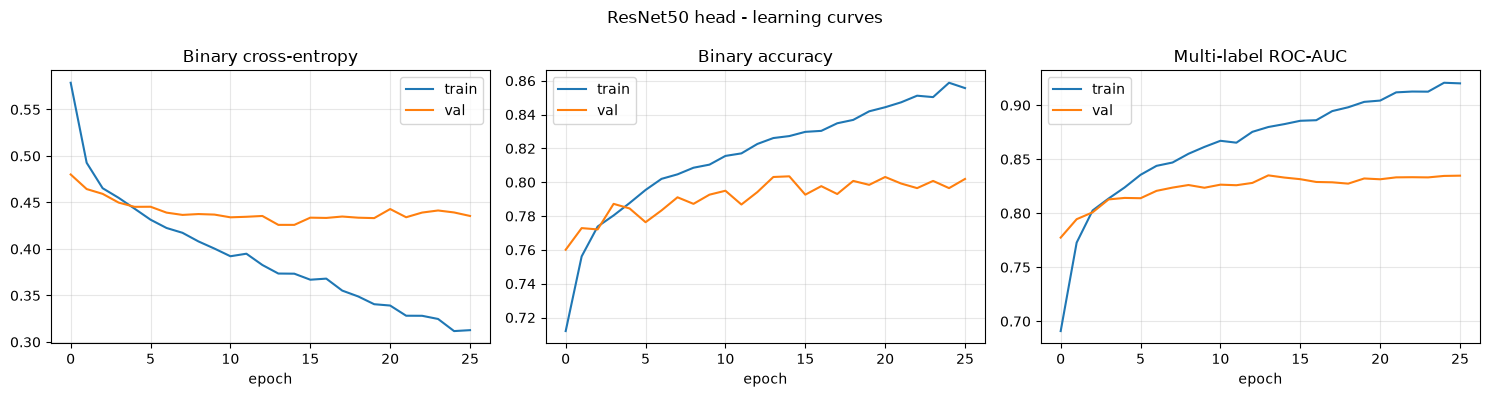

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist["loss"], label="train")
axes[0].plot(hist["val_loss"], label="val")
axes[0].set_title("Binary cross-entropy")
axes[1].plot(hist["binary_acc"], label="train")
axes[1].plot(hist["val_binary_acc"], label="val")
axes[1].set_title("Binary accuracy")
axes[2].plot(hist["auc"], label="train")
axes[2].plot(hist["val_auc"], label="val")
axes[2].set_title("Multi-label ROC-AUC")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("ResNet50 head - learning curves")
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "learning_curves.png")
plt.show()

## 7. Evaluation on the test set (threshold 0.5)

The test set is used only here. Metrics: subset accuracy, per-class
precision / recall / F1 / ROC-AUC, micro and macro averages.

In [12]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # saved optimizer state != fresh head
    head.load_weights(str(HEAD_WEIGHTS))
print("loaded best head weights:", HEAD_WEIGHTS.name)

prob_val = head.predict(X_val, verbose=0)
prob_test = head.predict(X_test, verbose=0)
pred_val = (prob_val >= 0.5).astype(int)
pred_test = (prob_test >= 0.5).astype(int)


def multilabel_metrics(y_true, pred, prob, average):
    return {
        "precision": precision_score(y_true, pred, average=average, zero_division=0),
        "recall": recall_score(y_true, pred, average=average, zero_division=0),
        "f1": f1_score(y_true, pred, average=average, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob, average=average),
    }


metrics = {
    "threshold": 0.5,
    "subset_accuracy": float(accuracy_score(y_test, pred_test)),
    "hamming_accuracy": float((y_test == pred_test).mean()),
    "micro": multilabel_metrics(y_test, pred_test, prob_test, "micro"),
    "macro": multilabel_metrics(y_test, pred_test, prob_test, "macro"),
    "per_class": {},
}
for i, c in enumerate(Config.class_names):
    metrics["per_class"][c] = {
        "precision": float(precision_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "recall": float(recall_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "f1": float(f1_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test[:, i], prob_test[:, i])),
        "support": int(y_test[:, i].sum()),
    }
save_json(metrics, Config.results_dir / "metrics" / "test_metrics.json")

print(f"subset accuracy : {metrics['subset_accuracy']:.4f}")
print(f"micro  P/R/F1   : {metrics['micro']['precision']:.3f} / "
      f"{metrics['micro']['recall']:.3f} / {metrics['micro']['f1']:.3f}")
print(f"macro  P/R/F1   : {metrics['macro']['precision']:.3f} / "
      f"{metrics['macro']['recall']:.3f} / {metrics['macro']['f1']:.3f}")
print(f"micro/macro AUC : {metrics['micro']['roc_auc']:.3f} / "
      f"{metrics['macro']['roc_auc']:.3f}")
pd.DataFrame(metrics["per_class"]).T

loaded best head weights: resnet50_head.weights.h5


subset accuracy : 0.4574
micro  P/R/F1   : 0.725 / 0.648 / 0.684
macro  P/R/F1   : 0.543 / 0.516 / 0.528
micro/macro AUC : 0.861 / 0.832


,precision,recall,f1,roc_auc,support
D00,0.706897,0.596364,0.646943,0.757071,275.0
D10,0.000000,0.000000,0.000000,0.874860,51.0
D20,0.735192,0.727586,0.731369,0.841515,290.0
D40,0.728625,0.739623,0.734082,0.854528,265.0


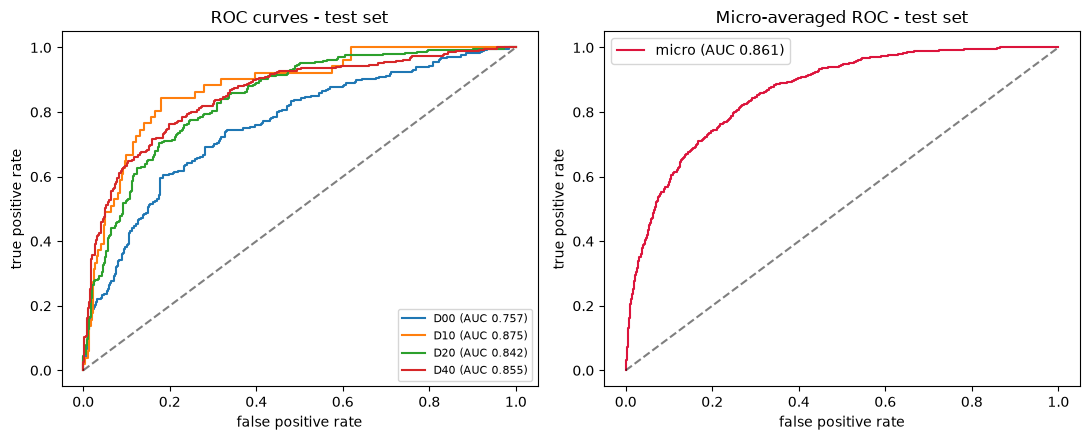

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, c in enumerate(Config.class_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], prob_test[:, i])
    axes[0].plot(fpr, tpr, label=f"{c} (AUC {metrics['per_class'][c]['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC curves - test set")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend(fontsize=8)
fpr, tpr, _ = roc_curve(y_test.ravel(), prob_test.ravel())
axes[1].plot(fpr, tpr, color="crimson", label=f"micro (AUC {metrics['micro']['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("Micro-averaged ROC - test set")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].legend()
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "roc_curves.png")
plt.show()

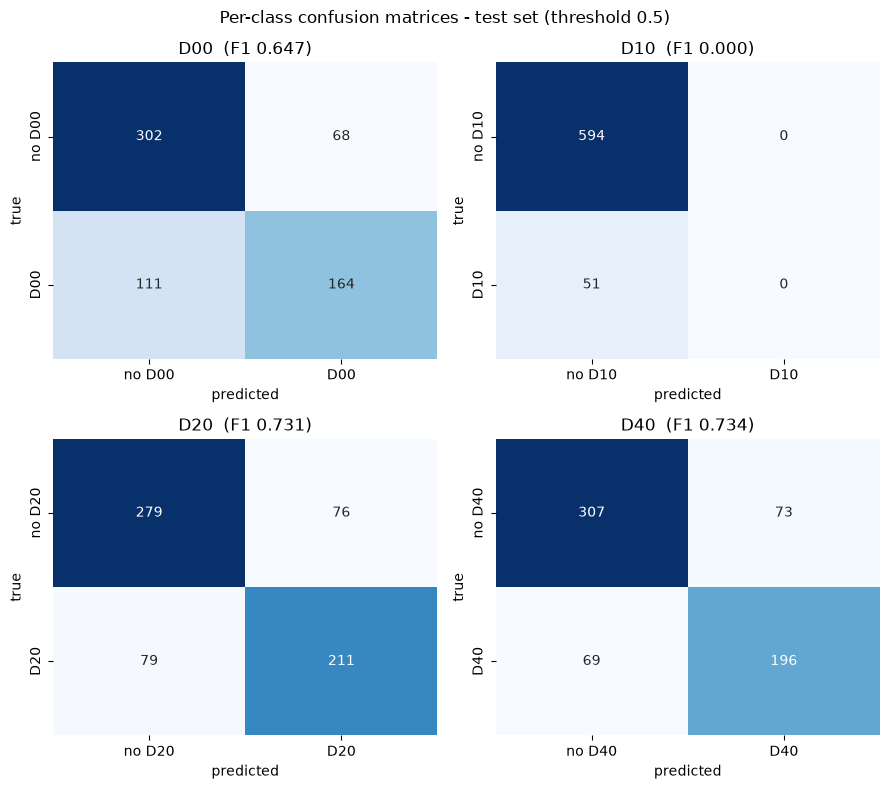

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for i, (c, ax) in enumerate(zip(Config.class_names, axes.ravel())):
    cm = confusion_matrix(y_test[:, i], pred_test[:, i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["no " + c, c], yticklabels=["no " + c, c])
    ax.set_title(f"{c}  (F1 {metrics['per_class'][c]['f1']:.3f})")
    ax.set_ylabel("true")
    ax.set_xlabel("predicted")
plt.suptitle("Per-class confusion matrices - test set (threshold 0.5)")
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "confusion_matrices.png")
plt.show()

## 8. Threshold tuning (validation only)

0.5 is rarely optimal for imbalanced labels. For each class we sweep
thresholds on the validation set, keep the one with the best F1, and re-score
the test set with those thresholds.

In [15]:
grid = np.arange(0.05, 0.95, 0.05)
best_thr = {}
for i, c in enumerate(Config.class_names):
    f1s = [f1_score(y_val[:, i], (prob_val[:, i] >= t).astype(int), zero_division=0)
           for t in grid]
    best_thr[c] = float(grid[int(np.argmax(f1s))])
print("tuned thresholds (from validation):", best_thr)

pred_test_tuned = np.stack(
    [(prob_test[:, i] >= best_thr[c]).astype(int)
     for i, c in enumerate(Config.class_names)], axis=1)

metrics_tuned = {
    "thresholds": best_thr,
    "subset_accuracy": float(accuracy_score(y_test, pred_test_tuned)),
    "micro": multilabel_metrics(y_test, pred_test_tuned, prob_test, "micro"),
    "macro": multilabel_metrics(y_test, pred_test_tuned, prob_test, "macro"),
    "per_class": {},
}
for i, c in enumerate(Config.class_names):
    metrics_tuned["per_class"][c] = {
        "precision": float(precision_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "recall": float(recall_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "f1": float(f1_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "roc_auc": metrics["per_class"][c]["roc_auc"],
        "support": int(y_test[:, i].sum()),
    }
save_json(metrics_tuned, Config.results_dir / "metrics" / "test_metrics_tuned.json")
save_json(best_thr, Config.results_dir / "metrics" / "thresholds.json")

cmp_df = pd.DataFrame({
    "F1 @0.5": {c: metrics["per_class"][c]["f1"] for c in Config.class_names},
    "F1 tuned": {c: metrics_tuned["per_class"][c]["f1"] for c in Config.class_names},
    "threshold": best_thr,
})
cmp_df.loc["micro"] = [metrics["micro"]["f1"], metrics_tuned["micro"]["f1"], np.nan]
cmp_df.loc["macro"] = [metrics["macro"]["f1"], metrics_tuned["macro"]["f1"], np.nan]
cmp_df.to_csv(Config.results_dir / "tables" / "per_class_metrics.csv")
print(f"micro F1  0.5 -> tuned: "
      f"{metrics['micro']['f1']:.4f} -> {metrics_tuned['micro']['f1']:.4f}")
print(f"macro F1  0.5 -> tuned: "
      f"{metrics['macro']['f1']:.4f} -> {metrics_tuned['macro']['f1']:.4f}")
cmp_df

tuned thresholds (from validation): {'D00': 0.35000000000000003, 'D10': 0.1, 'D20': 0.35000000000000003, 'D40': 0.6000000000000001}
micro F1  0.5 -> tuned: 0.6842 -> 0.6850
macro F1  0.5 -> tuned: 0.5281 -> 0.6411


,F1 @0.5,F1 tuned,threshold
D00,0.646943,0.665680,0.35
D10,0.000000,0.428571,0.10
D20,0.731369,0.748872,0.35
D40,0.734082,0.721174,0.60
micro,0.684242,0.685000,NaN
macro,0.528099,0.641075,NaN


## 9. Error analysis

* per-source results (Czech vs India),
* missed / spurious counts per label at the tuned thresholds.

In [16]:
rows = []
test_df = labels_df[labels_df["split"] == "test"].reset_index(drop=True)
for source, grp in test_df.groupby("source"):
    idx = grp.index.to_numpy()
    for name, pred in (("0.5", pred_test), ("tuned", pred_test_tuned)):
        rows.append({
            "source": source,
            "threshold": name,
            "n": len(idx),
            "micro_f1": f1_score(y_test[idx], pred[idx], average="micro", zero_division=0),
            "subset_acc": accuracy_score(y_test[idx], pred[idx]),
        })
source_df = pd.DataFrame(rows)
save_json(source_df.to_dict("records"),
          Config.results_dir / "metrics" / "source_metrics.json")
display(source_df)

,source,threshold,n,micro_f1,subset_acc
0,Czech,0.5,137,0.635762,0.503650
1,Czech,tuned,137,0.635945,0.197080
2,India,0.5,508,0.694952,0.444882
3,India,tuned,508,0.698595,0.362205


In [17]:
fn = ((y_test == 1) & (pred_test_tuned == 0)).sum(axis=0)
fp = ((y_test == 0) & (pred_test_tuned == 1)).sum(axis=0)
err_df = pd.DataFrame({
    "class": Config.class_names,
    "missed (FN)": fn,
    "spurious (FP)": fp,
    "support": y_test.sum(axis=0).astype(int),
}).set_index("class")
save_json(err_df.to_dict("index"),
          Config.results_dir / "metrics" / "label_errors.json")
display(err_df)
print(classification_report(y_test, pred_test_tuned,
                            target_names=Config.class_names, digits=3,
                            zero_division=0))

,missed (FN),spurious (FP),support
class,,,
D00,50,176,275
D10,12,92,51
D20,41,126,290
D40,93,40,265


              precision    recall  f1-score   support

         D00      0.561     0.818     0.666       275
         D10      0.298     0.765     0.429        51
         D20      0.664     0.859     0.749       290
         D40      0.811     0.649     0.721       265

   micro avg      0.612     0.778     0.685       881
   macro avg      0.584     0.773     0.641       881
weighted avg      0.655     0.778     0.696       881
 samples avg      0.643     0.788     0.675       881



## 10. Summary

Final numbers for the report; full JSON lives in
`results/IT23325814/metrics/`.

In [18]:
RUN["dataset"] = {
    "total_images": stats["total_images"],
    "labelled_images": int(len(labels_df)),
    "split_counts": leak["split_counts"],
    "shared_manifest_agreement": shared_check.get("agreement"),
}
RUN["test"] = {
    "micro_f1_05": metrics["micro"]["f1"],
    "macro_f1_05": metrics["macro"]["f1"],
    "micro_f1_tuned": metrics_tuned["micro"]["f1"],
    "macro_f1_tuned": metrics_tuned["macro"]["f1"],
    "micro_auc": metrics["micro"]["roc_auc"],
    "macro_auc": metrics["macro"]["roc_auc"],
    "subset_accuracy_05": metrics["subset_accuracy"],
    "thresholds": best_thr,
}
save_json(RUN, Config.results_dir / "metrics" / "run_summary.json")

print("ResNet50 (IT23325814) - final results")
print("=" * 56)
print(f"micro F1  @0.5 / tuned : {metrics['micro']['f1']:.4f} / "
      f"{metrics_tuned['micro']['f1']:.4f}")
print(f"macro F1  @0.5 / tuned : {metrics['macro']['f1']:.4f} / "
      f"{metrics_tuned['macro']['f1']:.4f}")
print(f"micro / macro ROC-AUC  : {metrics['micro']['roc_auc']:.4f} / "
      f"{metrics['macro']['roc_auc']:.4f}")
print(f"subset accuracy @0.5   : {metrics['subset_accuracy']:.4f}")
print(f"thresholds (tuned)     : {best_thr}")
print(f"trainable / frozen     : {trainable:,} / {frozen:,} params")
print(f"feature extraction     : {RUN['feature_seconds']} s")
print(f"head training          : {RUN['train_seconds']} s")
print("outputs ->", Config.results_dir)

ResNet50 (IT23325814) - final results
micro F1  @0.5 / tuned : 0.6842 / 0.6850
macro F1  @0.5 / tuned : 0.5281 / 0.6411
micro / macro ROC-AUC  : 0.8611 / 0.8320
subset accuracy @0.5   : 0.4574
thresholds (tuned)     : {'D00': 0.35000000000000003, 'D10': 0.1, 'D20': 0.35000000000000003, 'D40': 0.6000000000000001}
trainable / frozen     : 525,572 / 23,587,712 params
feature extraction     : 151.6 s
head training          : 7.8 s
outputs -> C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\results\IT23325814


## 11. Classify a new image

Uses the saved model (`src/IT23325814/models/resnet50_multilabel.keras`):

1. open any image and resize it to 224 x 224 with **bilinear** interpolation
   (the same resampler used when the features were extracted),
2. apply `resnet50.preprocess_input` (ImageNet mean subtraction, same as
   training),
3. `predict` -> four probabilities,
4. keep every class whose probability is >= its tuned threshold
   (`results/IT23325814/metrics/thresholds.json`).


image        : Czech_000020.jpg
probabilities: {'D00': 0.678, 'D10': 0.316, 'D20': 0.092, 'D40': 0.32}
thresholds   : {'D00': 0.35000000000000003, 'D10': 0.1, 'D20': 0.35000000000000003, 'D40': 0.6000000000000001}
predicted    : ['D00', 'D10']
ground truth : ['D10']


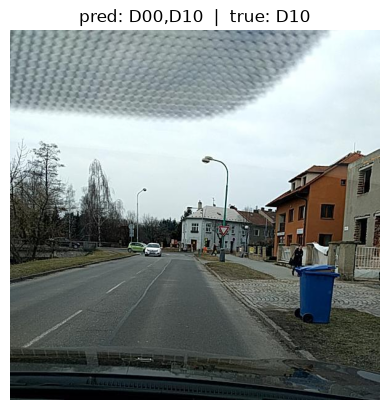

In [19]:
from tensorflow.keras.models import load_model as load_keras

saved_model = load_keras(str(Config.checkpoint_path), compile=False)
thresholds = load_json(Config.results_dir / "metrics" / "thresholds.json")

def classify(image_path):
    '''Return (probabilities, predicted labels) for one image.'''
    img = tf.keras.utils.load_img(image_path,
                                  target_size=(Config.img_size, Config.img_size),
                                  interpolation="bilinear")
    x = preprocess_input(np.expand_dims(tf.keras.utils.img_to_array(img), 0))
    probs = saved_model.predict(x, verbose=0)[0]
    probabilities = {c: round(float(p), 3) for c, p in zip(Config.class_names, probs)}
    predicted = [c for c, p in zip(Config.class_names, probs)
                 if p >= thresholds[c]]
    return probabilities, predicted

# change to your own file, e.g.  image_path = r"C:\photos\road.jpg"
image_path = test_paths[0]

probabilities, predicted = classify(image_path)
truth = [c for c, v in zip(Config.class_names, y_test[0]) if v] \
    if image_path in test_paths else None

print("image        :", Path(image_path).name)
print("probabilities:", probabilities)
print("thresholds   :", thresholds)
print("predicted    :", predicted or "no damage detected")
if truth is not None:
    print("ground truth :", truth or "no damage detected")

plt.imshow(plt.imread(image_path))
plt.title(f"pred: {','.join(predicted) or '-'}"
          + (f"  |  true: {','.join(truth) or '-'}" if truth else ""))
plt.axis("off")
plt.show()
